# Predictive Analysis- Feature Engineering

In this notebook, we create the following features from our master dataset.

In [68]:
import numpy as np
import json

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### Data Loading

The master dataset can be accessed on Google Drive [HERE](https://drive.google.com/drive/folders/18E3cOeuDJCxlE25XiR9HM2V8I7tKJkpF?usp=sharing)

In [25]:
# loading master dataset
import pandas as pd

file_path = '/content/drive/MyDrive/predictive-analysis-data/master_dataset_24h.csv.zip'
!unzip -o "{file_path}" -d "/content/data/"

df = pd.read_csv("/content/data/master_dataset_24h.csv")

df['datetime'] = pd.to_datetime(df['datetime'])
print(f"Data loaded with {len(df):,} rows.")

Archive:  /content/drive/MyDrive/predictive-analysis-data/master_dataset_24h.csv.zip
  inflating: /content/data/master_dataset_24h.csv  
  inflating: /content/data/__MACOSX/._master_dataset_24h.csv  
Data loaded with 876,100 rows.


### Creating the Features

#### Rolling Window Feature

We are capturing each machine's sensor behavior patterns over time by computing the mean and standard deviation of the sensors over the past 6 and 24 hours.<br>
 This enables our model to understand how a machine has been behaving recently and see if its sensors are in a stable stage or not.

In [26]:
# sort df by machine id then datetime
df = df.sort_values(['machineID', 'datetime']).reset_index(drop=True)

sensors = ['volt', 'rotate', 'pressure', 'vibration']
windows = [6, 24]
stats = ['mean', 'std']

rolling_features = []

for sensor in sensors:
  for window in windows:
    # grouping by machine and calculating the rolling stats
    roll = df.groupby('machineID')[sensor].rolling(
        window=window,
        min_periods=1
    )

    for stat in stats:
      # eg: volt_rolling_24h_stat
      feature_name = f'{sensor}_rolling_{window}h_{stat}'

      if stat == 'mean':
        df[feature_name] = roll.mean().reset_index(0, drop=True)
      elif stat == 'std':
        df[feature_name] = roll.std().reset_index(0, drop=True)

      rolling_features.append(feature_name)

# we need to handle NaN values that gets created on the first std calculation of every window
std_columns = [col for col in rolling_features if '_std' in col]
df[std_columns] = df[std_columns].fillna(0)

print(f"Total {len(rolling_features)} rolling window feature created")


Total 16 rolling window feature created


In [27]:
df.head(3)

,datetime,machineID,volt,rotate,pressure,vibration,model,age,error1,error2,...,rotate_rolling_24h_mean,rotate_rolling_24h_std,pressure_rolling_6h_mean,pressure_rolling_6h_std,pressure_rolling_24h_mean,pressure_rolling_24h_std,vibration_rolling_6h_mean,vibration_rolling_6h_std,vibration_rolling_24h_mean,vibration_rolling_24h_std
0,2015-01-01 06:00:00,1,176.217853,418.504078,113.077935,45.087686,model3,18,0,0,...,418.504078,0.000000,113.077935,0.000000,113.077935,0.000000,45.087686,0.000000,45.087686,0.000000
1,2015-01-01 07:00:00,1,162.879223,402.747490,95.460525,43.413973,model3,18,0,0,...,410.625784,11.141591,104.269230,12.457390,104.269230,12.457390,44.250829,1.183494,44.250829,1.183494
2,2015-01-01 08:00:00,1,170.989902,527.349825,75.237905,34.178847,model3,18,0,0,...,449.533798,67.849599,94.592122,18.934956,94.592122,18.934956,40.893502,5.874970,40.893502,5.874970


#### Lag Features

Here, we are creating lag features to capture each machine's sensor values from the past few hours, along with the rate of change in those values over the past hour. These features help our model track trends and sudden shifts in sensor behavior over time.

In [28]:
lag_features = []
lag_hours = [1, 3]

for sensor in sensors:
  # get the sensor's value from 'l' hours before
  for lag in lag_hours:
    feature_name = f'{sensor}_lag_{lag}h'
    df[feature_name] = df.groupby('machineID')[sensor].shift(lag)
    lag_features.append(feature_name)

  # get the rate of change in sensor value from previous (1) hour
  feature_name = f'{sensor}_change_1h'
  df[feature_name] = df[sensor] - df.groupby('machineID')[sensor].shift(1)
  lag_features.append(feature_name)

# handle any Nan values at start of each machine's time series
df[lag_features] = df[lag_features].fillna(0)

print(f"Created {len(lag_features)} lag features")


Created 12 lag features


In [29]:
df.head(3)

,datetime,machineID,volt,rotate,pressure,vibration,model,age,error1,error2,...,volt_change_1h,rotate_lag_1h,rotate_lag_3h,rotate_change_1h,pressure_lag_1h,pressure_lag_3h,pressure_change_1h,vibration_lag_1h,vibration_lag_3h,vibration_change_1h
0,2015-01-01 06:00:00,1,176.217853,418.504078,113.077935,45.087686,model3,18,0,0,...,0.00000,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.000000
1,2015-01-01 07:00:00,1,162.879223,402.747490,95.460525,43.413973,model3,18,0,0,...,-13.33863,418.504078,0.0,-15.756589,113.077935,0.0,-17.617410,45.087686,0.0,-1.673713
2,2015-01-01 08:00:00,1,170.989902,527.349825,75.237905,34.178847,model3,18,0,0,...,8.11068,402.747490,0.0,124.602336,95.460525,0.0,-20.222621,43.413973,0.0,-9.235126


#### Critical Events Feature

We capture the critical events of each machine over time. Specifically, for each machine, we compute the:
- Number of error in the last 24 hours
- Hours since last error and last maintenance
- Days since last failure
- Total number of error, maintenance and failures encountered to date

At the end of this section, we would have total 7 new features created.



In [30]:
# list to track the 3 different events: Error, Maintenance, Failure
event_features = []

In [31]:
# Error Event Computation

# calculates the cumulative error count of each machine in its prev 24 hours
df['error_count_last_24_h'] = df.groupby('machineID')['has_error'].rolling(
    window=24,
    min_periods=1
).sum().reset_index(0, drop=True)
event_features.append('error_count_last_24_h')

# calculates the hour since last error for all machines
df['hours_since_last_error'] = np.nan
for machine_id in df['machineID'].unique():
  # boolean mask to identify all rows of current machine
  mask = df['machineID'] == machine_id
  machine_df = df[mask].copy()

  # indices where a error occurred for the machine
  error_indices = machine_df[machine_df['has_error'] == 1].index

  for i in machine_df.index:
    # most recent error before this time
    prev_errors = error_indices[error_indices < i]
    if len(prev_errors) > 0:
      last_error_index = prev_errors[-1]
      last_error_time = machine_df.loc[last_error_index, 'datetime']
      current_time = machine_df.loc[i, 'datetime']
      dif_hours = (current_time - last_error_time).total_seconds()/3600
      df.loc[i, 'hours_since_last_error'] = dif_hours
    else:
      # if no previous error for the machine, using a large placeholder
      df.loc[i, 'hours_since_last_error'] = 999

event_features.append('hours_since_last_error')

In [32]:
# Maintenance Event Computation

df['hours_since_last_maintenance'] = np.nan
for machine_id in df['machineID'].unique():
  # boolean mask to identify all rows of current machine
  mask = df['machineID'] == machine_id
  machine_df = df[mask].copy()

  maint_indices = machine_df[machine_df['has_maintenance'] == 1].index

  for i in machine_df.index:
    prev_maint = maint_indices[maint_indices < i]
    if len(prev_maint) > 0:
      last_maint_index = prev_maint[-1]
      last_maint_time = machine_df.loc[last_maint_index, 'datetime']
      current_time = machine_df.loc[i, 'datetime']
      dif_hours = (current_time - last_maint_time).total_seconds()/3600
      df.loc[i, 'hours_since_last_maintenance'] = dif_hours
    else:
      df.loc[i, 'hours_since_last_maintenance'] = 999

event_features.append('hours_since_last_maintenance')


In [33]:
# Failure Event Computation- we need to only consider past failures to avoid data leakage

df['days_since_last_failure'] = np.nan
for machine_id in df['machineID'].unique():
    mask = df['machineID'] == machine_id
    machine_df = df[mask].copy()

    failure_indices = machine_df[machine_df['has_failure'] == 1].index

    for i in machine_df.index:
        # most recent failure before this timestamp
        prev_failures = failure_indices[failure_indices < i]
        if len(prev_failures) > 0:
          last_failure_index = prev_failures[-1]
          last_failure_time = machine_df.loc[last_failure_index, 'datetime']
          current_time = machine_df.loc[i, 'datetime']
          dif_days = (current_time - last_failure_time).total_seconds()/(3600*24)
          df.loc[i, 'days_since_last_failure'] = dif_days
        else:
            df.loc[i, 'days_since_last_failure'] = 999

event_features.append('days_since_last_failure')


In [47]:
# Cumulative event counts
df['total_errors_to_date'] = df.groupby('machineID')['has_error'].cumsum()
df['total_maintenances_to_date'] = df.groupby('machineID')['has_maintenance'].cumsum()
df['total_failures_to_date'] = df.groupby('machineID')['has_failure'].cumsum()

event_features.extend(['total_errors_to_date', 'total_maintenances_to_date', 'total_failures_to_date'])

In [35]:
print(f"Total {len(event_features)} event history features created")

Total 7 event history features created


In [ ]:
for event in event_features:
  print(event, sep="\n")

### Machine-specific Features

Here, we captures & convert some important machine-specific features for our ML model, like:
- One-hot encode the 4 different models of machine
- Get age squared as a polynomial feature to capture the non-linear relation between age & failure (target)
- Machine's sensor baseline deviation: how does the current sensor reading compare to its average

In [37]:
machine_features = []

In [38]:
# one-hot encoding the 4 machine models
dummies_model = pd.get_dummies(df['model'], drop_first=True)

# merge the one-hot encoded columns into master df
df = pd.concat([df, dummies_model], axis=1)

machine_features.extend(dummies_model.columns.tolist())

In [40]:
# compute age squared
df['age_squared'] = df['age'] ** 2
machine_features.append('age_squared')

In [41]:
# compute machine baseline deviations
for sensor in sensors:
  # each machine's average sensor value
  machine_avg = df.groupby('machineID')[sensor].transform('mean')

  feature_name = f'{sensor}_deviation_from_machine_avg'
  df[feature_name] = df[sensor] - machine_avg

  machine_features.append(feature_name)

In [42]:
print(f"Total {len(machine_features)} machine-specific features created.")


Total 8 machine-specific features created.


In [45]:
# Summary of all created features
all_new_features = (rolling_features + lag_features + event_features +
                   machine_features)

print(f"\nTotal new features created: {len(all_new_features)}")
print(f"Rolling window: {len(rolling_features)}")
print(f"Lag features: {len(lag_features)}")
print(f"Event history: {len(event_features)}")
print(f"Machine-specific: {len(machine_features)}")


Total new features created: 43
Rolling window: 16
Lag features: 12
Event history: 7
Machine-specific: 8


In [50]:
df.head(5)

,datetime,machineID,volt,rotate,pressure,vibration,model,age,error1,error2,...,total_maintenances_to_date,total_failures_to_date,model2,model3,model4,age_squared,volt_deviation_from_machine_avg,rotate_deviation_from_machine_avg,pressure_deviation_from_machine_avg,vibration_deviation_from_machine_avg
0,2015-01-01 06:00:00,1,176.217853,418.504078,113.077935,45.087686,model3,18,0,0,...,0,0,False,True,False,324,5.383955,-27.832424,12.409630,4.501377
1,2015-01-01 07:00:00,1,162.879223,402.747490,95.460525,43.413973,model3,18,0,0,...,0,0,False,True,False,324,-7.954675,-43.589012,-5.207781,2.827664
2,2015-01-01 08:00:00,1,170.989902,527.349825,75.237905,34.178847,model3,18,0,0,...,0,0,False,True,False,324,0.156005,81.013324,-25.430401,-6.407462
3,2015-01-01 09:00:00,1,162.462833,346.149335,109.248561,41.122144,model3,18,0,0,...,0,0,False,True,False,324,-8.371064,-100.187167,8.580255,0.535835
4,2015-01-01 10:00:00,1,157.610021,435.376873,111.886648,25.990511,model3,18,0,0,...,0,0,False,True,False,324,-13.223876,-10.959629,11.218342,-14.595798


In [51]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 876100 entries, 0 to 876099
Data columns (total 72 columns):
 #   Column                                Non-Null Count   Dtype         
---  ------                                --------------   -----         
 0   datetime                              876100 non-null  datetime64[ns]
 1   machineID                             876100 non-null  int64         
 2   volt                                  876100 non-null  float64       
 3   rotate                                876100 non-null  float64       
 4   pressure                              876100 non-null  float64       
 5   vibration                             876100 non-null  float64       
 6   model                                 876100 non-null  object        
 7   age                                   876100 non-null  int64         
 8   error1                                876100 non-null  int64         
 9   error2                                876100 non-null  int6

### Train/Val/Test split (Temporal)

Here, we perfom a temporal split on our master dataset as we have a time series data, so we cannot do a random split. <br>
We choose the split as:
- Train: 2015-01-01 to 2015-10-31 (70%)
- Val: 2015-11-01 to 2015-11-30 (10%)
- Test: 2015-12-01 to 2015-12-31 (20%)



In [52]:
# defining split dates
train_end = pd.Timestamp('2015-10-31 23:59:59')
val_end = pd.Timestamp('2015-11-30 23:59:59')

# perfoming the splits
train_mask = df['datetime'] <= train_end
val_mask = (df['datetime'] > train_end) & (df['datetime'] <= val_end)
test_mask = df['datetime'] > val_end

train_df = df[train_mask].copy()
val_df = df[val_mask].copy()
test_df = df[test_mask].copy()


In [56]:
print(f"\nSplit Summary:")
print(f"Train: {len(train_df):,} rows")
print(f"Val:   {len(val_df):,} rows")
print(f"Test:  {len(test_df):,} rows")

# target distribution across splits
print(f"\nTarget Distribution:")
print(f"Train: {train_df['target_failure_24h'].value_counts()[1]:,} failures ({train_df['target_failure_24h'].mean()*100:.2f}%)")
print(f"Val:   {val_df['target_failure_24h'].value_counts()[1]:,} failures ({val_df['target_failure_24h'].mean()*100:.2f}%)")
print(f"Test:  {test_df['target_failure_24h'].value_counts()[1]:,} failures ({test_df['target_failure_24h'].mean()*100:.2f}%)")


Split Summary:
Train: 729,000 rows
Val:   72,000 rows
Test:  75,100 rows

Target Distribution:
Train: 14,502 failures (1.99%)
Val:   1,374 failures (1.91%)
Test:  1,308 failures (1.74%)


In [57]:
# extracting to dataset

# excluded identifiers, timestamps, failure event flags, and targets
# need to try including error flags
exclude_cols = ['machineID', 'datetime', 'model',
                'failure_comp1', 'failure_comp2', 'failure_comp3', 'failure_comp4',
                'has_error',
                'target_failure_24h', 'target_comp1_24h', 'target_comp2_24h',
                'target_comp3_24h', 'target_comp4_24h']
feature_cols = [col for col in df.columns if col not in exclude_cols]

print(f"Total {len(feature_cols)} features.")


Total 59 features.


In [58]:
# seperating features & target
X_train = train_df[feature_cols]
y_train = train_df['target_failure_24h']

X_val = val_df[feature_cols]
y_val = val_df['target_failure_24h']

X_test = test_df[feature_cols]
y_test = test_df['target_failure_24h']

# storing metadata for later
train_meta = train_df[['machineID', 'datetime', 'target_failure_24h']].copy()
val_meta = val_df[['machineID', 'datetime', 'target_failure_24h']].copy()
test_meta = test_df[['machineID', 'datetime', 'target_failure_24h']].copy()

### Feature Scaling

We are scaling our dataset on the training data to standarize the range of all feature variables.

In [63]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# fit on training data: calculates mean & std
scaler.fit(X_train)

# transform all datasets: applies the transformation using value from scaler
X_train_scaled = scaler.transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# converting to df for easier export
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=feature_cols, index=X_train.index)
X_val_scaled_df = pd.DataFrame(X_val_scaled, columns=feature_cols, index=X_val.index)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=feature_cols, index=X_test.index)


In [65]:
print(f"Scaling Verification:")
print(f"Train set- Mean: {X_train_scaled_df.mean().mean():.4f}, Std: {X_train_scaled_df.std().mean():.4f}")
print(f"Val set - Mean: {X_val_scaled_df.mean().mean():.4f}, Std: {X_val_scaled_df.std().mean():.4f}")
print(f"Test set - Mean: {X_test_scaled_df.mean().mean():.4f}, Std: {X_test_scaled_df.std().mean():.4f}")

Scaling Verification:
Train set- Mean: -0.0000, Std: 1.0000
Val set - Mean: 0.0727, Std: 0.9636
Test set - Mean: 0.0920, Std: 0.9731


### Exporting Datasets

In [67]:
import os
OUTPUT_PATH = "drive/MyDrive/predictive-analysis-data/"
os.makedirs(OUTPUT_PATH, exist_ok=True)

# Save the scaled features with its metadata
train_final = pd.concat([train_meta.reset_index(drop=True),
                         X_train_scaled_df.reset_index(drop=True)], axis=1)
val_final = pd.concat([val_meta.reset_index(drop=True),
                       X_val_scaled_df.reset_index(drop=True)], axis=1)
test_final = pd.concat([test_meta.reset_index(drop=True),
                        X_test_scaled_df.reset_index(drop=True)], axis=1)

# export as csv
train_final.to_csv(f'{OUTPUT_PATH}train.csv', index=False)
val_final.to_csv(f'{OUTPUT_PATH}val.csv', index=False)
test_final.to_csv(f'{OUTPUT_PATH}test.csv', index=False)

In [73]:
# saving feature names metadata
feature_metadata = {
    'feature_columns': feature_cols,
    'n_features': len(feature_cols),
    'rolling_features': rolling_features,
    'lag_features': lag_features,
    'event_features': event_features,
    'machine_features': machine_features,
    'target_column': 'target_failure_24h'
    }


with open(f'{OUTPUT_PATH}feature_metadata.json', 'w') as f:
  json.dump(feature_metadata, f, indent=2)

In [70]:
# saving split metadata

split_metadata = {
    'dataset_info': {
        'total_rows': len(df),
        'date_range': {
            'start': str(df['datetime'].min()),
            'end': str(df['datetime'].max())
        }
    },
    'split_info': {
        'train': {
            'rows': len(train_df),
            'date_range': f"{train_df['datetime'].min()} to {train_df['datetime'].max()}",
            'failure_rate': float(train_df['target_failure_24h'].mean()),
            'n_failures': int(train_df['target_failure_24h'].sum())
        },
        'val': {
            'rows': len(val_df),
            'date_range': f"{val_df['datetime'].min()} to {val_df['datetime'].max()}",
            'failure_rate': float(val_df['target_failure_24h'].mean()),
            'n_failures': int(val_df['target_failure_24h'].sum())
        },
        'test': {
            'rows': len(test_df),
            'date_range': f"{test_df['datetime'].min()} to {test_df['datetime'].max()}",
            'failure_rate': float(test_df['target_failure_24h'].mean()),
            'n_failures': int(test_df['target_failure_24h'].sum())
        }
    },
    'class_imbalance': {
        'train_ratio': f"1:{int(1/train_df['target_failure_24h'].mean())}",
        'val_ratio': f"1:{int(1/val_df['target_failure_24h'].mean())}",
        'test_ratio': f"1:{int(1/test_df['target_failure_24h'].mean())}"
    },
    'scaling_method': 'StandardScaler'
}

with open(f'{OUTPUT_PATH}split_metadata.json', 'w') as f:
    json.dump(split_metadata, f, indent=2)

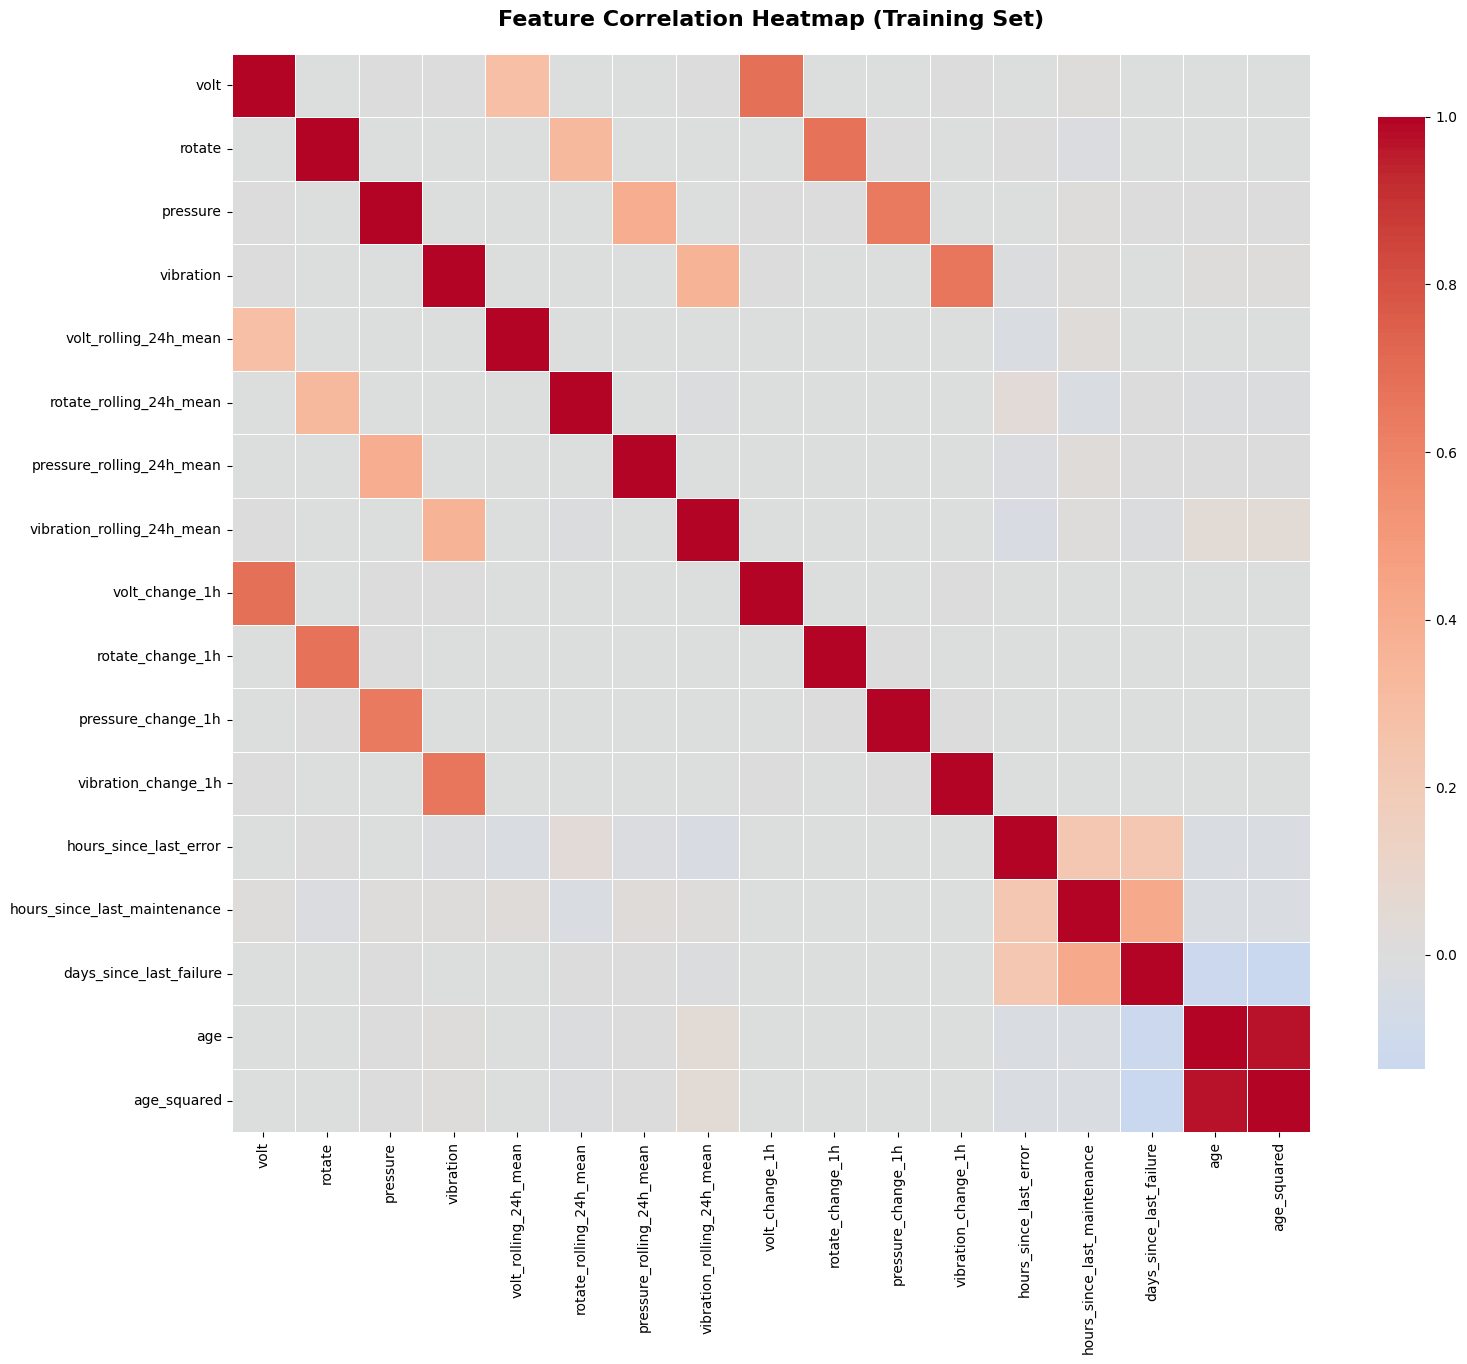

In [72]:
# Correlation heatmap for top features
import matplotlib.pyplot as plt
import seaborn as sns

# Select a subset of features for correlation analysis
correlation_features = (
    sensors +  # Original sensors
    [f'{s}_rolling_24h_mean' for s in sensors] +  # Rolling means
    [f'{s}_change_1h' for s in sensors] +  # Changes
    ['hours_since_last_error', 'hours_since_last_maintenance', 'days_since_last_failure'] +
    ['age', 'age_squared']
)

# Calculate correlation matrix on training data
corr_matrix = X_train_scaled_df[correlation_features].corr()

# Create heatmap
plt.figure(figsize=(16, 14))
sns.heatmap(corr_matrix,
            annot=False,
            cmap='coolwarm',
            center=0,
            square=True,
            linewidths=0.5,
            cbar_kws={"shrink": 0.8})
plt.title('Feature Correlation Heatmap (Training Set)', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()